<a href="https://colab.research.google.com/github/Maryam-71295/Insurance-Cost-Prediction-Internship-Task4/blob/main/Insurance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Medical Insurance Cost Prediction**

This project aims to predict medical insurance charges using demographic and lifestyle features such as age, BMI, smoking status, number of children, and region.

The notebook demonstrates a complete machine learning workflow including:

Data exploration
Data preprocessing
Exploratory Data Analysis (EDA)
Feature encoding
Baseline model training
Regularized regression models
Hyperparameter tuning
Final model evaluation

# **Problem Statement**

Medical insurance costs vary significantly based on an individual's health, lifestyle, and demographic characteristics.

The objective of this project is to build a regression model capable of predicting medical insurance charges using available features in the dataset.

The target variable is:

charges → medical insurance cost

The goal is to understand which features influence insurance charges the most and build a model that can accurately estimate these costs.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Loading the Dataset

The dataset is loaded using pandas for further analysis and preprocessing.

In [2]:
df=pd.read_csv("/content/insurance.csv")

In [3]:
df.shape

(1338, 7)

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Checking Missing Values

Missing values can affect model performance and analysis.

The dataset is checked for null values to determine whether imputation is required.

No missing values were found in the dataset.

In [7]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [8]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print(num_cols)
print(cat_cols)

Index(['age', 'bmi', 'children', 'charges'], dtype='object')
Index(['sex', 'smoker', 'region'], dtype='object')


# Exploratory Data Analysis (EDA)

EDA helps understand the structure and distribution of data.

In this project, EDA is divided into two categories:

Numerical feature analysis
Categorical feature analysis
This allows us to understand the behavior of each feature type separately.

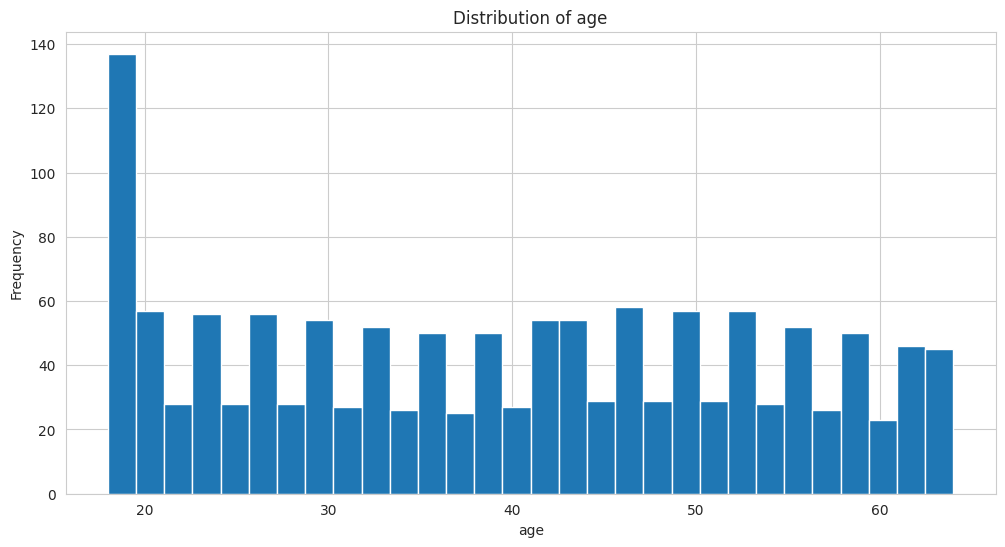

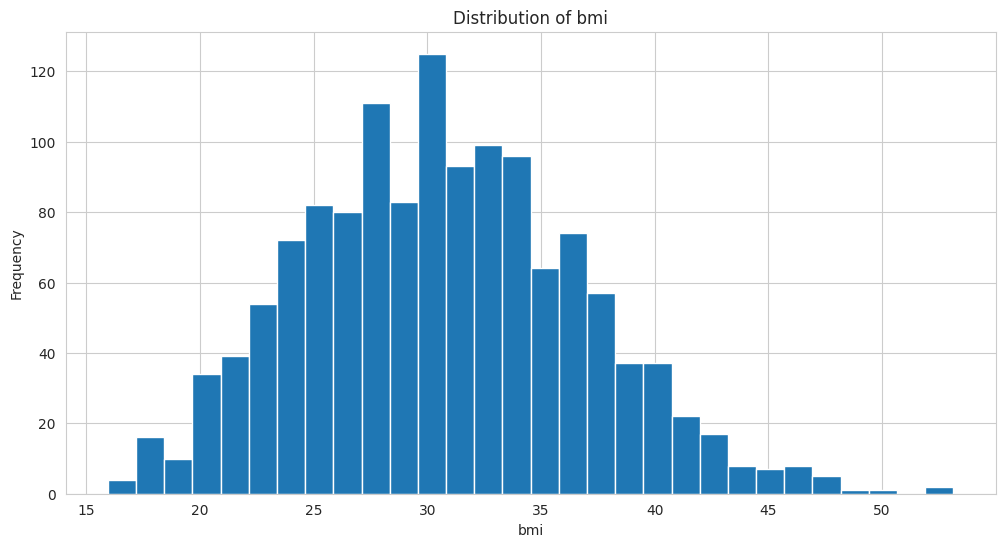

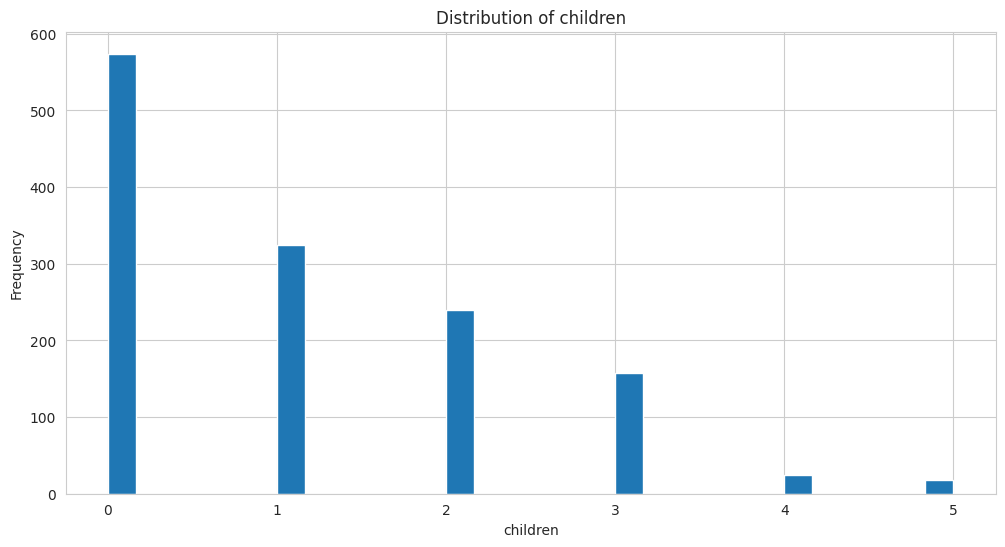

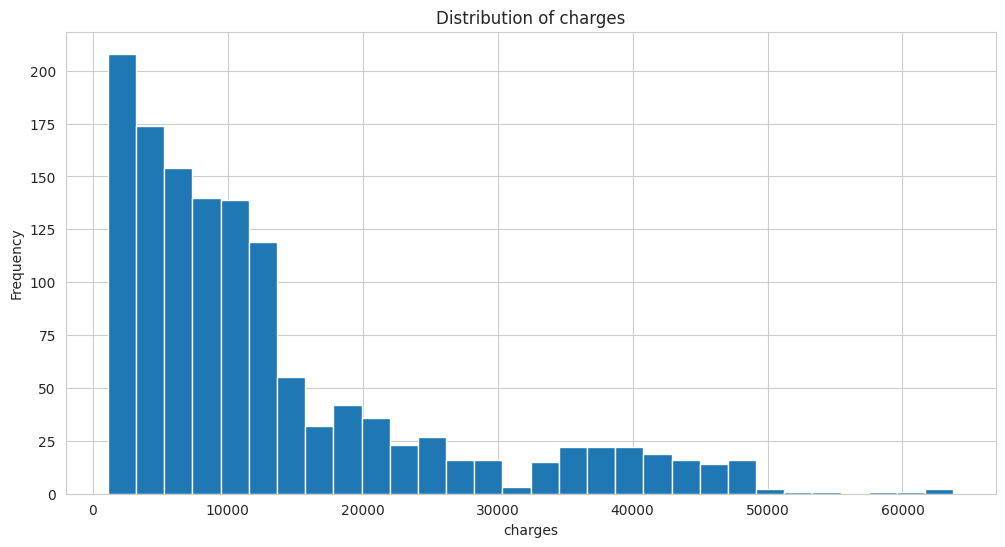

In [9]:
for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [10]:
df["charges"].skew()

np.float64(1.5158796580240388)

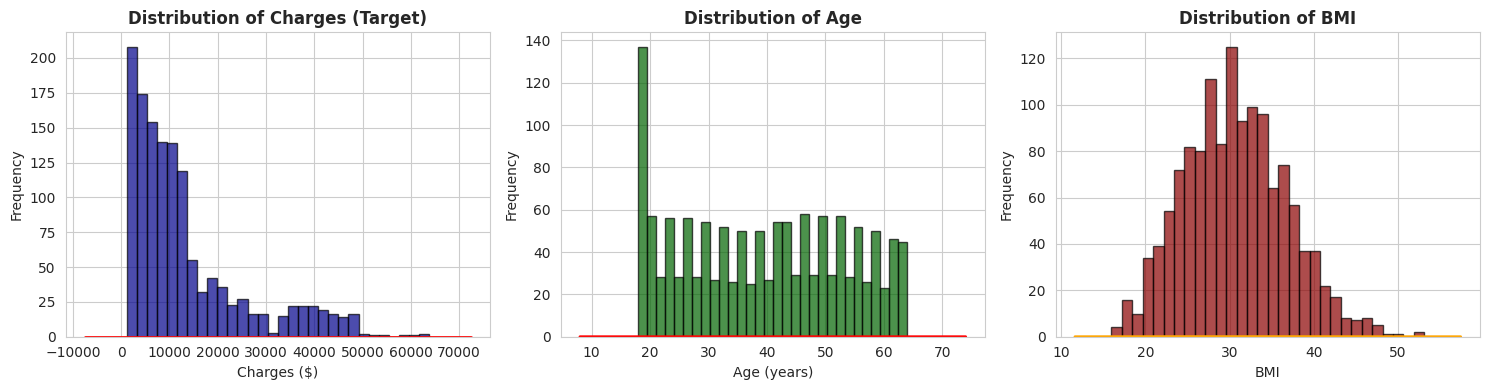

Univariate Statistics:
Charges - Mean: $13270.42, Std: $12110.01
Age - Mean: 39.21 years, Std: 14.05
BMI - Mean: 30.66, Std: 6.10


In [18]:
# Univariate Analysis - Distribution of key numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Charges distribution (Target variable)
axes[0].hist(df['charges'], bins=30, color='darkblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Distribution of Charges (Target)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frequency')
sns.kdeplot(df['charges'], ax=axes[0], color='red', linewidth=2)

# Age distribution
axes[1].hist(df['age'], bins=30, color='darkgreen', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution of Age', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Frequency')
sns.kdeplot(df['age'], ax=axes[1], color='red', linewidth=2)

# BMI distribution
axes[2].hist(df['bmi'], bins=30, color='darkred', alpha=0.7, edgecolor='black')
axes[2].set_title('Distribution of BMI', fontsize=12, fontweight='bold')
axes[2].set_xlabel('BMI')
axes[2].set_ylabel('Frequency')
sns.kdeplot(df['bmi'], ax=axes[2], color='orange', linewidth=2)

plt.tight_layout()
plt.show()

print("Univariate Statistics:")
print(f"Charges - Mean: ${df['charges'].mean():.2f}, Std: ${df['charges'].std():.2f}")
print(f"Age - Mean: {df['age'].mean():.2f} years, Std: {df['age'].std():.2f}")
print(f"BMI - Mean: {df['bmi'].mean():.2f}, Std: {df['bmi'].std():.2f}")

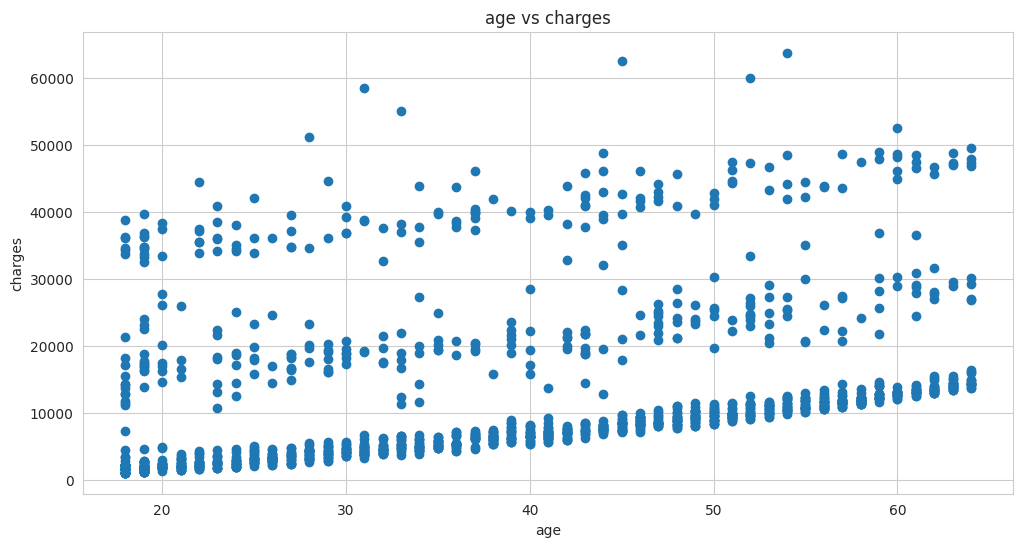

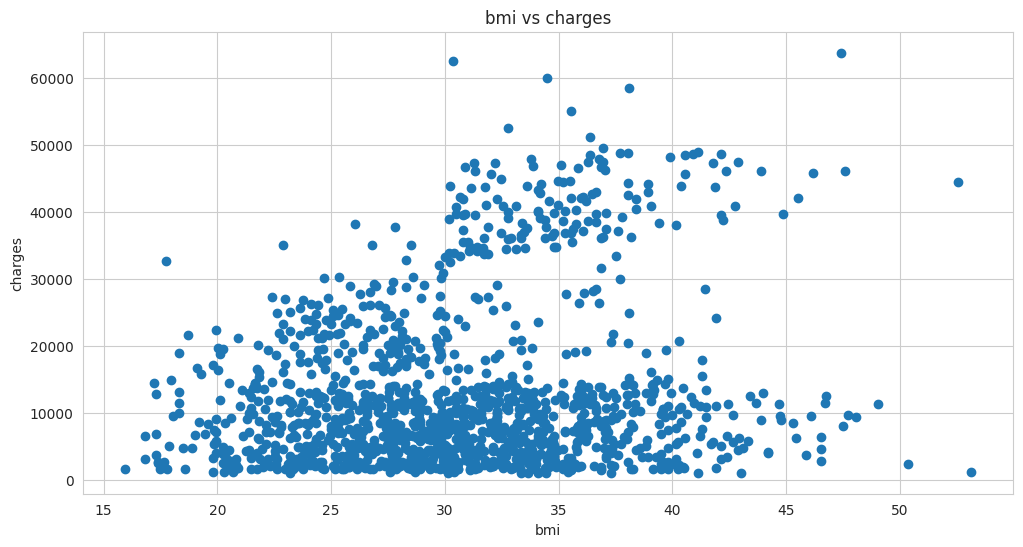

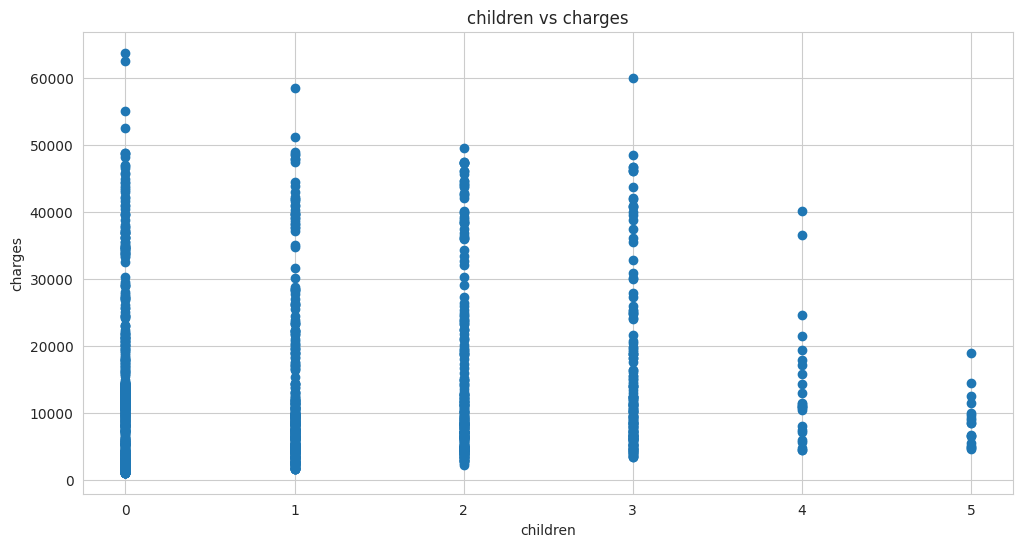

In [11]:
target = "charges"

for col in num_cols:
    if col != target:
        plt.figure()
        plt.scatter(df[col], df[target])
        plt.title(f"{col} vs {target}")
        plt.xlabel(col)
        plt.ylabel(target)
        plt.show()

Generating Pairplot - shows scatter plots and distributions for all numeric features...


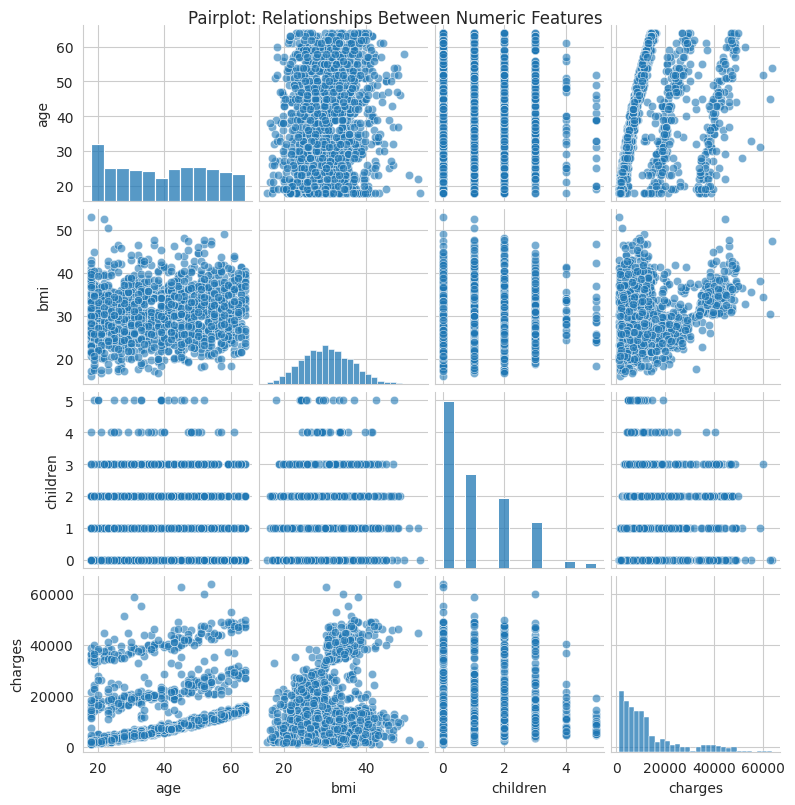

In [19]:
# Pairplot - Shows relationships between all numeric features
print("Generating Pairplot - shows scatter plots and distributions for all numeric features...")
pairplot = sns.pairplot(df, diag_kind='hist', plot_kws={'alpha': 0.6}, height=2)
plt.suptitle('Pairplot: Relationships Between Numeric Features', y=1.001)
plt.show()

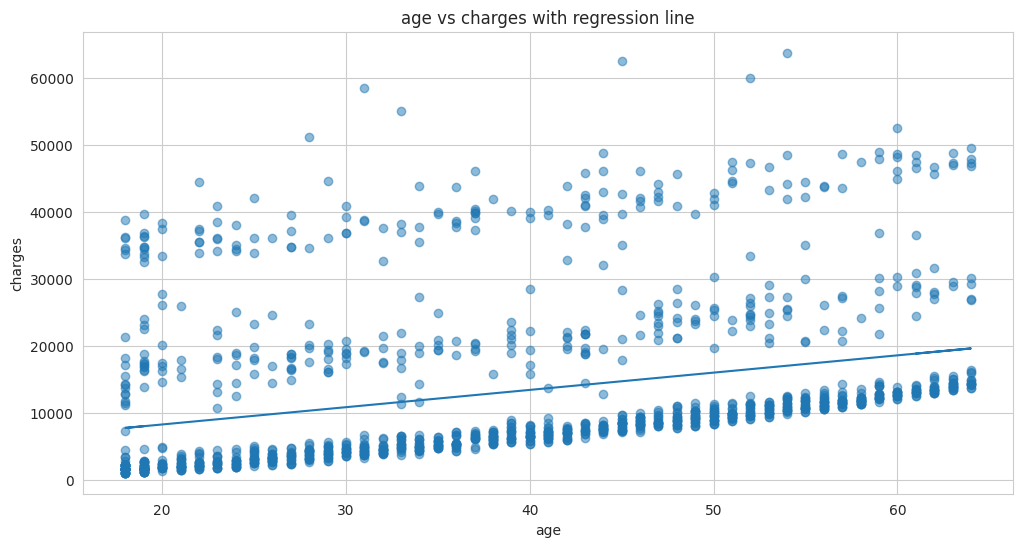

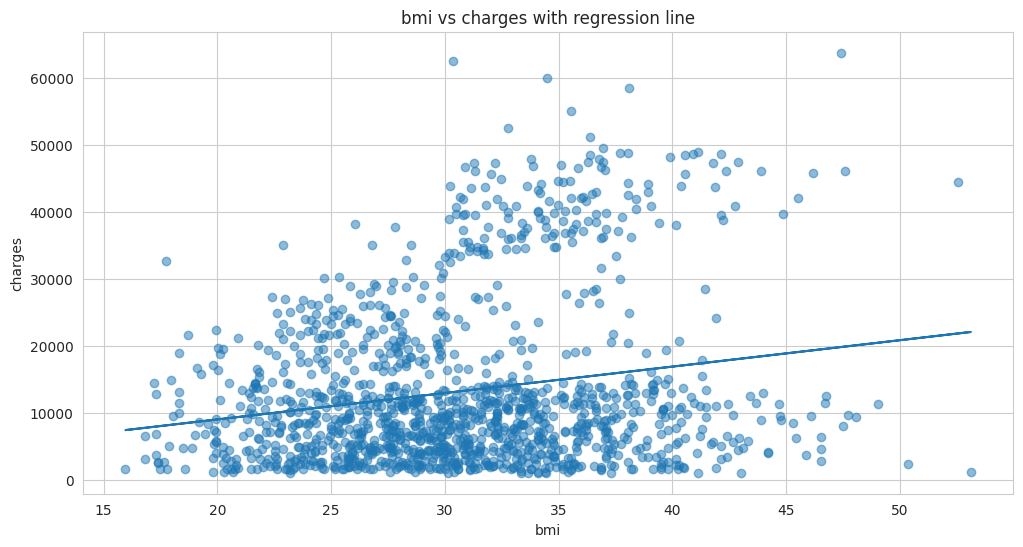

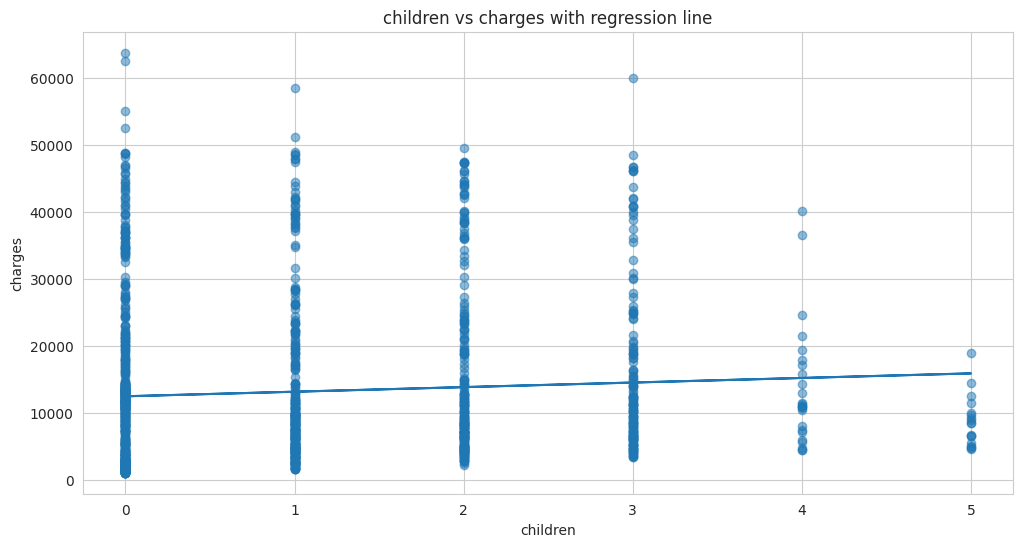

In [12]:
for col in num_cols:

    if col != target:

        x = df[col]
        y = df[target]

        plt.figure()
        plt.scatter(x, y, alpha=0.5)

        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m*x + b)

        plt.title(f"{col} vs {target} with regression line")
        plt.xlabel(col)
        plt.ylabel(target)

        plt.show()

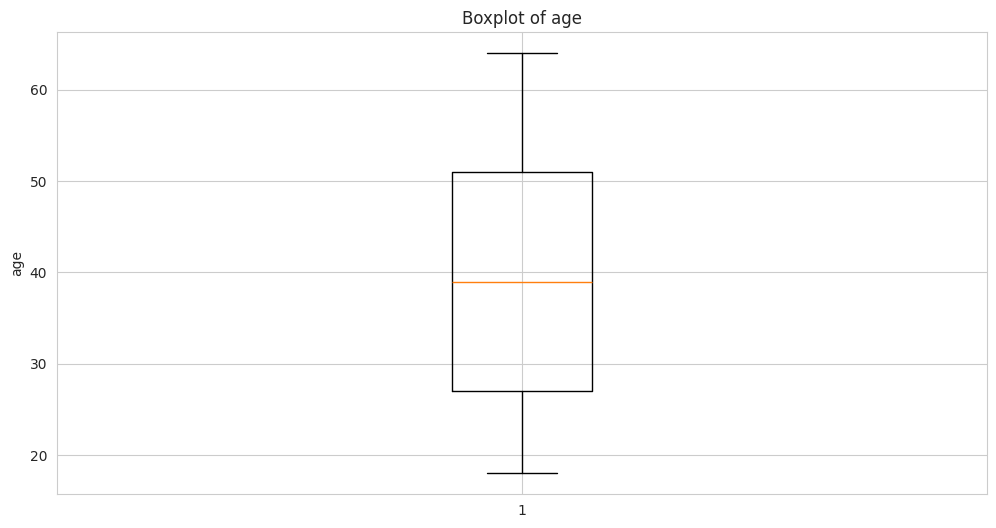

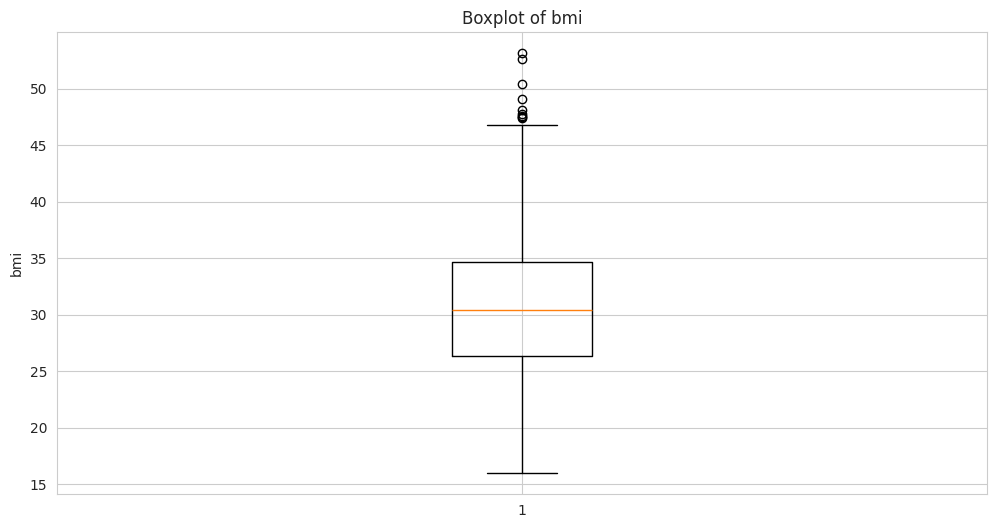

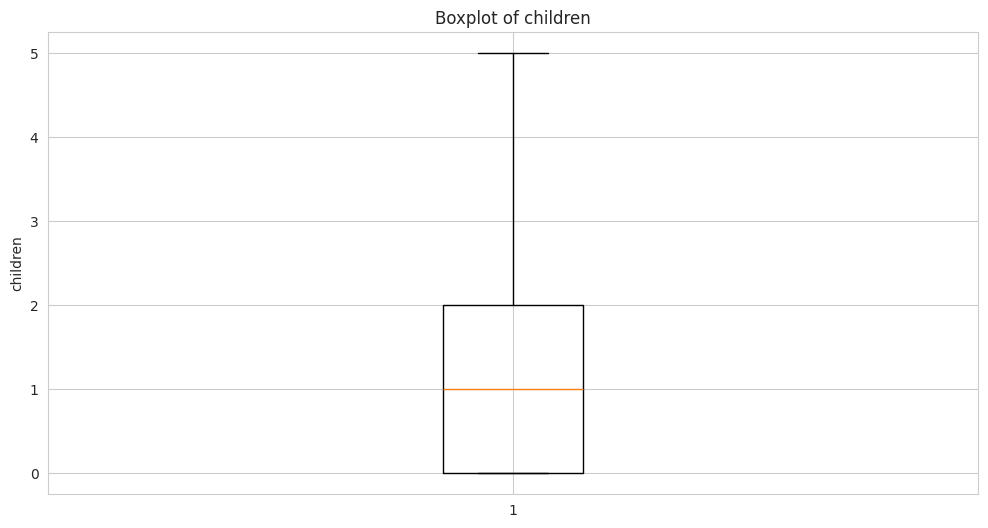

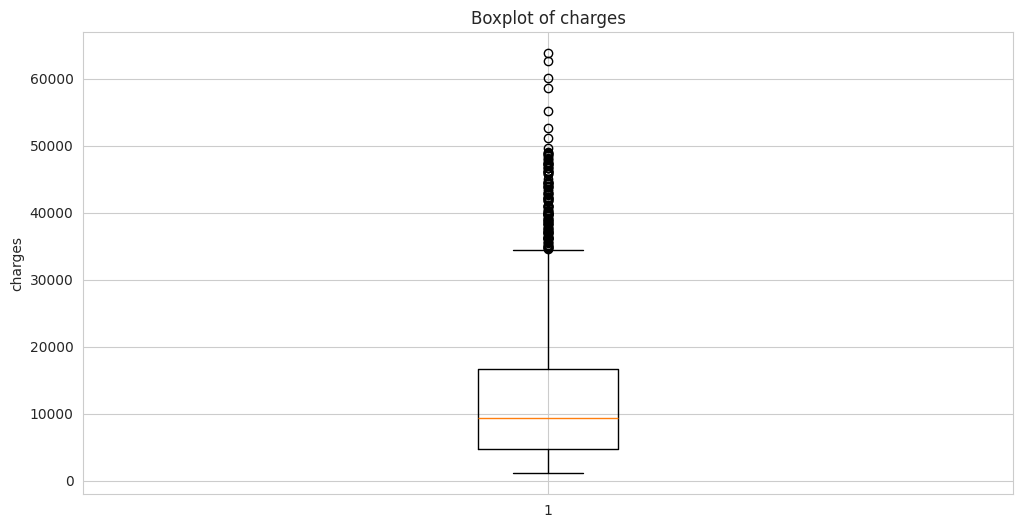

In [13]:
for col in num_cols:

    plt.figure()
    plt.boxplot(df[col])

    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)

    plt.show()

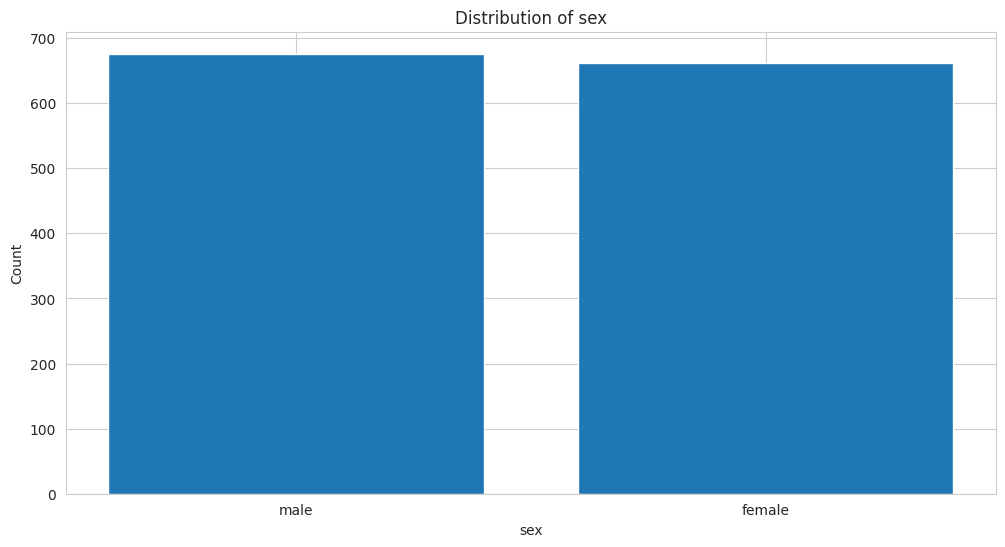

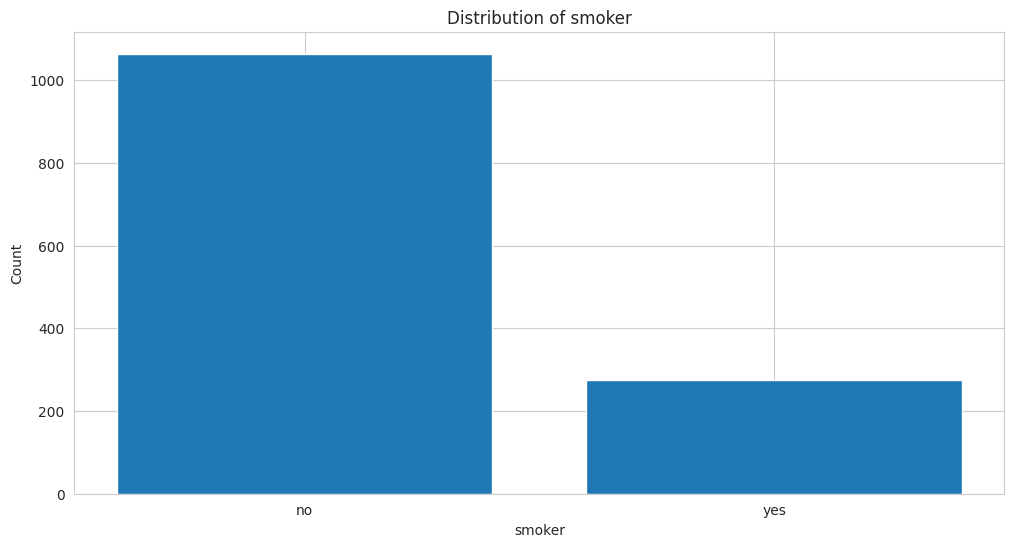

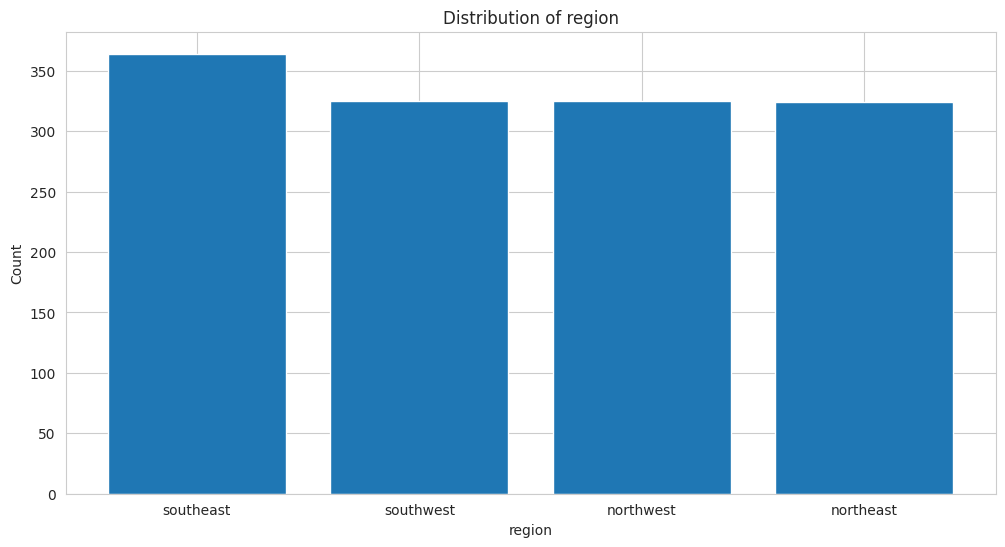

In [14]:
for col in cat_cols:

    counts = df[col].value_counts()

    plt.figure()
    plt.bar(counts.index, counts.values)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

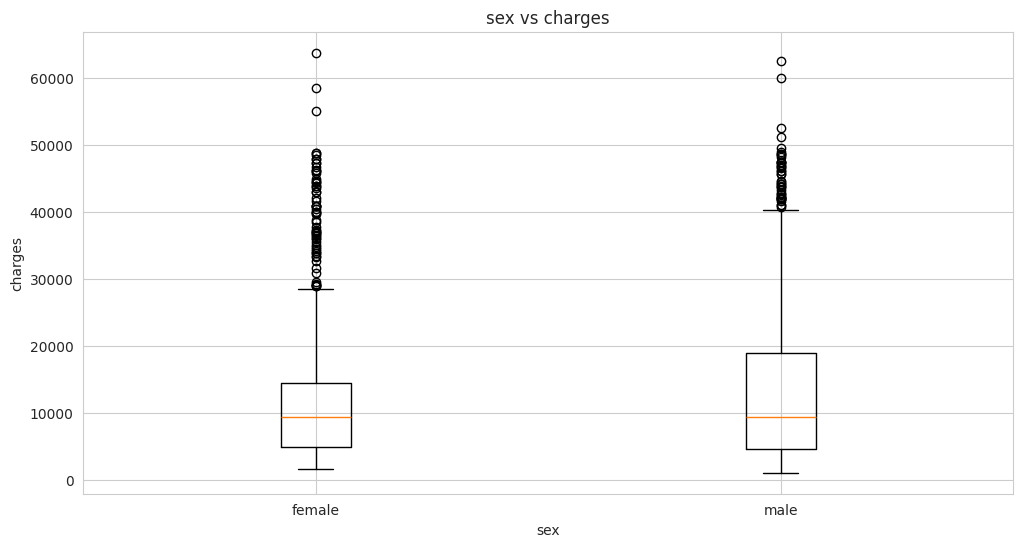

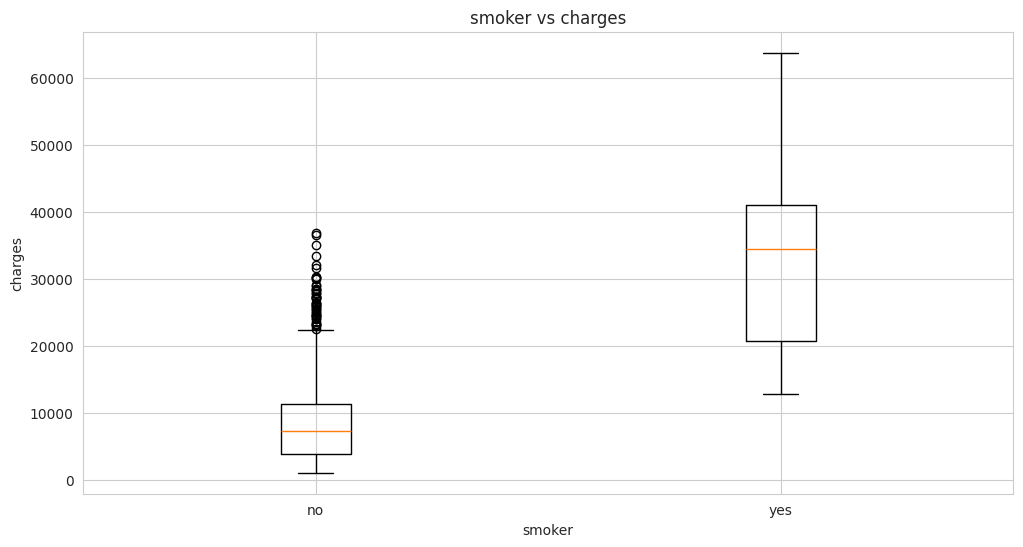

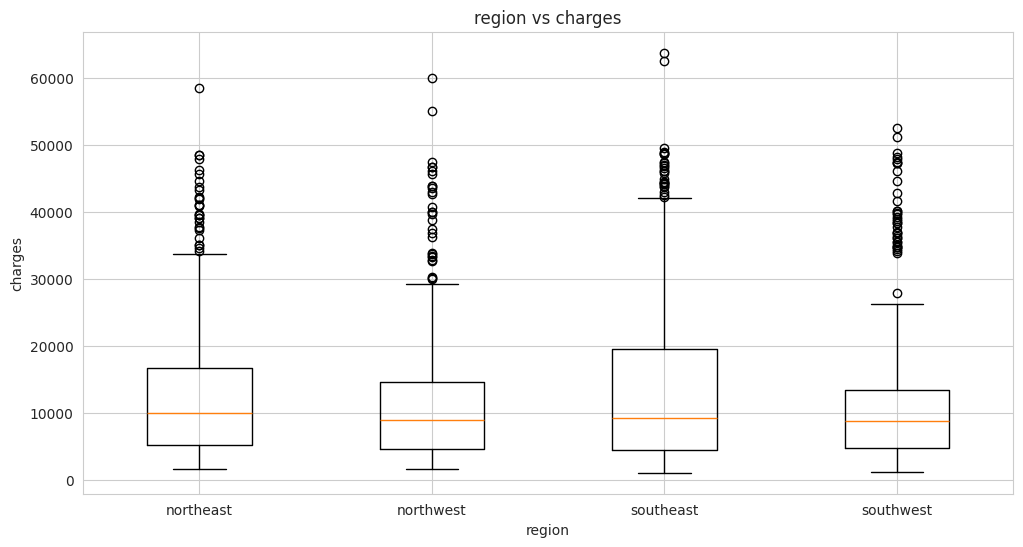

In [15]:
target = "charges"

for col in cat_cols:

    groups = df.groupby(col)[target].apply(list)

    plt.figure()
    plt.boxplot(groups, labels=groups.index)

    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f"{col} vs {target}")

    plt.show()

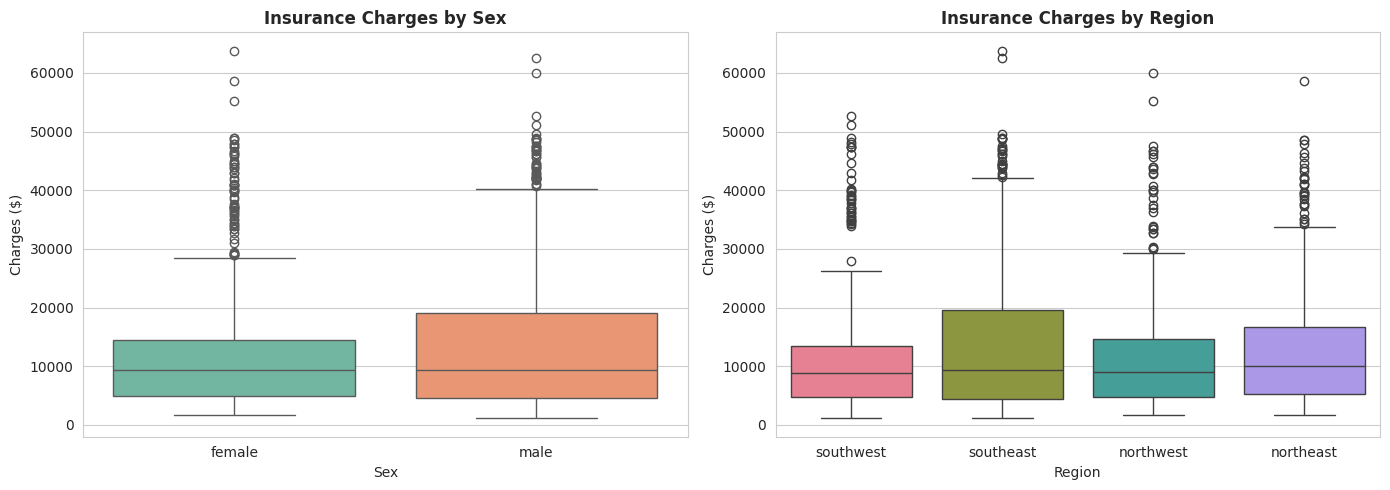

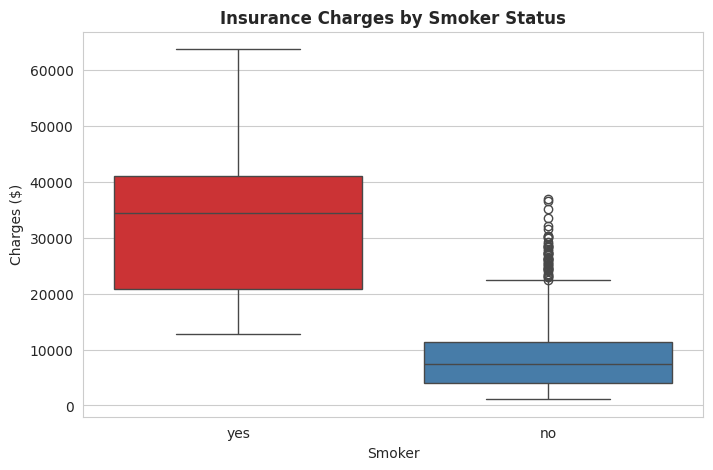

In [20]:
# Bivariate Analysis - Relationship with Categorical Variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Charges by Sex
sns.boxplot(data=df, x='sex', y='charges', palette='Set2', ax=axes[0])
axes[0].set_title('Insurance Charges by Sex', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Charges ($)')
axes[0].set_xlabel('Sex')

# Charges by Region
sns.boxplot(data=df, x='region', y='charges', palette='husl', ax=axes[1])
axes[1].set_title('Insurance Charges by Region', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Charges ($)')
axes[1].set_xlabel('Region')

plt.tight_layout()
plt.show()

# Charges by Smoker Status
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='charges', palette='Set1', ax=ax)
ax.set_title('Insurance Charges by Smoker Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Charges ($)')
ax.set_xlabel('Smoker')
plt.show()

# Encoding Categorical Variables

Machine learning models require numerical inputs.

---



Categorical features were converted to numerical form using One-Hot Encoding.

This creates binary columns representing each category.

In [25]:
# One-hot encode categorical variables
# This converts categorical columns into multiple binary columns
print("Encoding categorical variables: sex, region, smoker")
X_encoded = pd.get_dummies(X, drop_first=False)  # Keep all categories for clarity
X_encoded = X_encoded.astype(int)

print("\nEncoded features shape:", X_encoded.shape)
print("Encoded features:\n", X_encoded.head())
print("\nFeature names after encoding:")
print(X_encoded.columns.tolist())

Encoding categorical variables: sex, region, smoker

Encoded features shape: (1338, 11)
Encoded features:
    age  bmi  children  sex_female  sex_male  smoker_no  smoker_yes  \
0   19   27         0           1         0          0           1   
1   18   33         1           0         1          1           0   
2   28   33         3           0         1          1           0   
3   33   22         0           0         1          1           0   
4   32   28         0           0         1          1           0   

   region_northeast  region_northwest  region_southeast  region_southwest  
0                 0                 0                 0                 1  
1                 0                 0                 1                 0  
2                 0                 0                 1                 0  
3                 0                 1                 0                 0  
4                 0                 1                 0                 0  

Feature names a

# Correlation Analysis

Correlation analysis helps identify relationships between features and the target variable.

A correlation matrix was computed after encoding categorical variables.

Key observation:

Smoking status shows the strongest correlation with insurance charges.

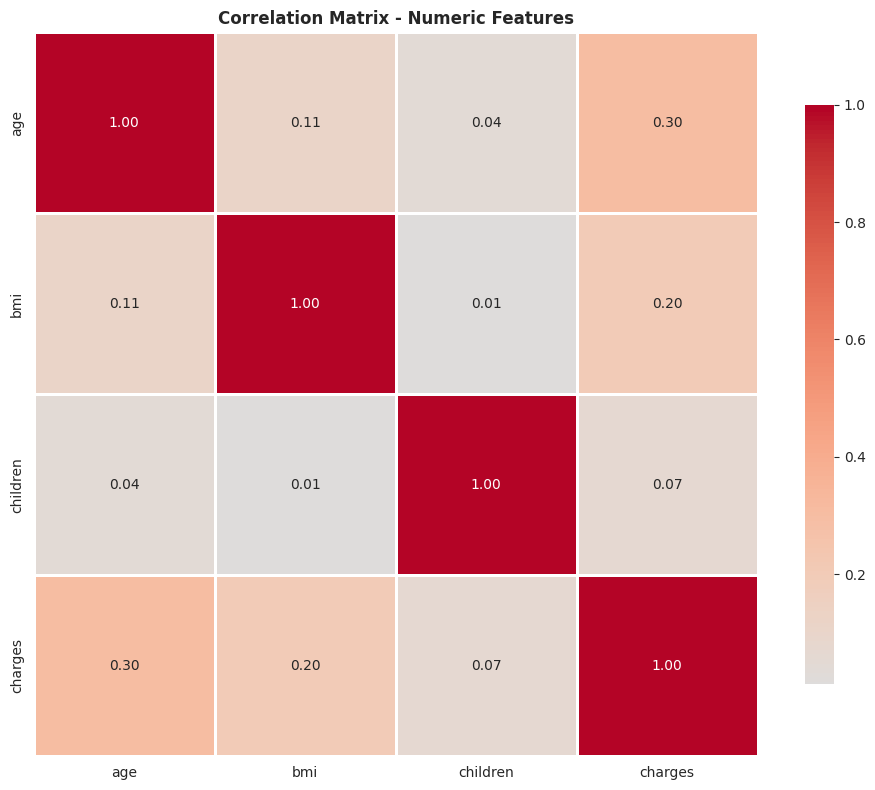


Key Correlations with Target (Charges):
charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


In [21]:
# Correlation Analysis - Multivariate relationship
fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Numeric Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Correlations with Target (Charges):")
charges_corr = correlation_matrix['charges'].sort_values(ascending=False)
print(charges_corr)

# **Separate features (X) and target (y)**

In [23]:
# Separate features (X) and target (y)
X = df.drop('charges', axis=1)
y = df['charges']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:\n", X.head())
print("\nTarget:\n", y.head())

Features shape: (1338, 6)
Target shape: (1338,)

Features:
    age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest

Target:
 0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


# Train-Test Split

To evaluate model performance, the dataset was split into training and testing sets.

Training set → used to train the model
Testing set → used to evaluate performance on unseen data

In [26]:
# Train/Test Split - CRITICAL: Do this BEFORE scaling to prevent data leakage
print("Splitting data into training (85%) and testing (15%) sets...")
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.15, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Total features: {X_train.shape[1]}")
print(f"\nTarget variable (Charges) statistics:")
print(f"Training set - Mean: ${y_train.mean():.2f}, Std: ${y_train.std():.2f}")
print(f"Testing set - Mean: ${y_test.mean():.2f}, Std: ${y_test.std():.2f}")

Splitting data into training (85%) and testing (15%) sets...
Training set size: 1137 samples
Testing set size: 201 samples
Total features: 11

Target variable (Charges) statistics:
Training set - Mean: $13285.25, Std: $12068.86
Testing set - Mean: $13186.57, Std: $12370.49


In [27]:
x_train,x_test,y_train,y_test= train_test_split(X_encoded ,y, test_size=0.15 , random_state=42)

# **Feature Scaling (Applied After Train/Test Split)**

StandardScaler standardizes features by removing the mean and dividing by the standard deviation
Prevents features with larger scales from dominating the model
Essential for distance-based models (KNN, SVM) and gradient descent methods
MUST be fit on training data only, then applied to test data

In [28]:
# Step 4: Apply StandardScaler
# Fit scaler on TRAINING data only, then transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for reference
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaling applied successfully!")
print("\nScaled Training Data Statistics:")
print(f"Mean: {X_train_scaled.mean(axis=0)[:5]}... (showing first 5)")
print(f"Std: {X_train_scaled.std(axis=0)[:5]}... (showing first 5)")
print("\nScaled Testing Data Statistics:")
print(f"Mean: {X_test_scaled.mean(axis=0)[:5]}... (showing first 5)")
print(f"Std: {X_test_scaled.std(axis=0)[:5]}... (showing first 5)")

Scaling applied successfully!

Scaled Training Data Statistics:
Mean: [ 1.71855103e-16  7.81159560e-17  7.81159560e-19 -8.12405942e-17
  8.12405942e-17]... (showing first 5)
Std: [1. 1. 1. 1. 1.]... (showing first 5)

Scaled Testing Data Statistics:
Mean: [-0.01980777  0.11809332 -0.00037823  0.07673261 -0.07673261]... (showing first 5)
Std: [0.98645436 0.96661614 0.94560489 0.99874284 0.99874284]... (showing first 5)


In [29]:
# Initialize regression models for training
models = {
    'Linear Regression': LinearRegression(),
    'Support Vector Regressor': SVR(kernel='rbf', C=100, epsilon=0.1),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10,
                                          min_samples_split=10, max_features=0.7),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100,
                                                   learning_rate=0.1, max_depth=5)
}

print("Models initialized. Training on scaled features...")
print("="*60)

Models initialized. Training on scaled features...


# **Model Training & Evaluation**

**Models Used:**

*Linear Regression:* Simple, interpretable baseline model that assumes linear relationship

*Support Vector Regressor (SVR):* Non-linear model using support vector machines (benefits from scaling)

*Decision Tree:* Creates decision rules to split features hierarchically

*Random Forest:* Ensemble of decision trees, reduces overfitting through averaging

*K-Nearest Neighbors (KNN):* Instance-based learning (requires scaling)

*Gradient Boosting:* Sequential tree-building that improves on previous errors

All models trained on scaled features to ensure fair comparison and optimal performance for distance/gradient-based algorithms.

In [30]:
# Train all models on scaled data and evaluate performance
results = {}
trained_models = {}

for name, model in models.items():
    # Train on scaled training data
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    # Make predictions on scaled test data
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {
        'R² Score': r2 * 100,
        'MAE': mae,
        'RMSE': rmse
    }

    print(f"\n{name}:")
    print(f"  R² Score: {r2*100:.2f}%")
    print(f"  MAE (Mean Absolute Error): ${mae:.2f}")
    print(f"  RMSE (Root Mean Squared Error): ${rmse:.2f}")

print("\n" + "="*60)

# Summary table
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R² Score', ascending=False)
print("\nModel Comparison (sorted by R² Score):")
print(results_df)


Linear Regression:
  R² Score: 79.77%
  MAE (Mean Absolute Error): $4035.33
  RMSE (Root Mean Squared Error): $5550.57

Support Vector Regressor:
  R² Score: 36.33%
  MAE (Mean Absolute Error): $5558.64
  RMSE (Root Mean Squared Error): $9846.26

Decision Tree:
  R² Score: 73.20%
  MAE (Mean Absolute Error): $3242.14
  RMSE (Root Mean Squared Error): $6387.87

Random Forest:
  R² Score: 86.86%
  MAE (Mean Absolute Error): $2552.67
  RMSE (Root Mean Squared Error): $4472.88

KNN:
  R² Score: 79.74%
  MAE (Mean Absolute Error): $3499.73
  RMSE (Root Mean Squared Error): $5554.89

Gradient Boosting:
  R² Score: 84.06%
  MAE (Mean Absolute Error): $2838.15
  RMSE (Root Mean Squared Error): $4927.24


Model Comparison (sorted by R² Score):
                           R² Score          MAE         RMSE
Random Forest             86.860898  2552.673842  4472.875139
Gradient Boosting         84.055927  2838.150205  4927.238362
Linear Regression         79.766659  4035.326379  5550.572026
KNN   

# **Cross-Validation Analysis**

Cross-Validation tests model stability by splitting data into multiple folds:

Trains on k-1 folds and tests on the remaining fold, rotating through all folds

Provides more reliable performance estimate than single test set

Shows model variance - lower standard deviation means more stable predictions

We use 5-Fold Cross-Validation for a balance between thoroughness and computation time

In [31]:
# 5-Fold Cross-Validation with scaling properly handled
from sklearn.pipeline import Pipeline

print("Performing 5-Fold Cross-Validation...")
print("=" * 70)

cv_results = {}

for name, model in models.items():
    # Create a pipeline to ensure scaling happens within each CV fold
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # Perform cross-validation
    cv_scores = cross_val_score(pipeline, X_encoded, y, cv=5, scoring='r2')

    cv_results[name] = {
        'Mean R² Score': cv_scores.mean() * 100,
        'Std Dev': cv_scores.std() * 100,
        'CV Scores': cv_scores * 100
    }

    print(f"\n{name}:")
    print(f"  Mean R² Score: {cv_scores.mean()*100:.2f}%")
    print(f"  Standard Deviation: {cv_scores.std()*100:.2f}%")
    print(f"  Fold Scores: {[f'{score:.2f}%' for score in cv_scores*100]}")

print("\n" + "=" * 70)

Performing 5-Fold Cross-Validation...

Linear Regression:
  Mean R² Score: 74.69%
  Standard Deviation: 2.50%
  Fold Scores: ['76.12%', '70.67%', '77.90%', '73.26%', '75.49%']

Support Vector Regressor:
  Mean R² Score: 30.54%
  Standard Deviation: 0.99%
  Fold Scores: ['31.36%', '29.66%', '31.74%', '30.78%', '29.14%']

Decision Tree:
  Mean R² Score: 72.66%
  Standard Deviation: 3.50%
  Fold Scores: ['75.84%', '66.39%', '74.39%', '71.37%', '75.31%']

Random Forest:
  Mean R² Score: 85.44%
  Standard Deviation: 3.39%
  Fold Scores: ['87.35%', '79.39%', '88.96%', '84.22%', '87.30%']

KNN:
  Mean R² Score: 78.72%
  Standard Deviation: 2.67%
  Fold Scores: ['79.07%', '74.55%', '82.77%', '77.69%', '79.52%']

Gradient Boosting:
  Mean R² Score: 84.16%
  Standard Deviation: 3.19%
  Fold Scores: ['85.57%', '78.39%', '87.86%', '83.59%', '85.38%']



# **Feature Importance Analysis**

Feature Importance shows which features have the greatest impact on predictions:

Tree-based Models (RandomForest, GradientBoosting): Calculate importance based on how much each feature decreases impurity across all splits

Linear Models: Importance shown as absolute coefficient values

Why it matters: Understand which features drive predictions, helps with feature selection and business insights

In [32]:
# Extract feature importance from Random Forest (best performing tree-based model)
print("Feature Importance Analysis")
print("=" * 70)

# Random Forest Feature Importance
rf_model = trained_models['Random Forest']
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nRandom Forest - Top 10 Most Important Features:")
print(feature_importance_rf.head(10))

# Gradient Boosting Feature Importance
gb_model = trained_models['Gradient Boosting']
feature_importance_gb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n\nGradient Boosting - Top 10 Most Important Features:")
print(feature_importance_gb.head(10))

# Linear Regression Coefficients
lr_model = trained_models['Linear Regression']
feature_importance_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_,
    'Abs_Coefficient': np.abs(lr_model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("\n\nLinear Regression - Top 10 Features by Absolute Coefficient:")
print(feature_importance_lr[['Feature', 'Coefficient']].head(10))

print("\n" + "=" * 70)

Feature Importance Analysis

Random Forest - Top 10 Most Important Features:
             Feature  Importance
6         smoker_yes    0.406782
5          smoker_no    0.255308
1                bmi    0.175208
0                age    0.133348
2           children    0.014005
7   region_northeast    0.003771
9   region_southeast    0.002737
8   region_northwest    0.002439
10  region_southwest    0.002348
3         sex_female    0.002161


Gradient Boosting - Top 10 Most Important Features:
             Feature  Importance
6         smoker_yes    0.414107
5          smoker_no    0.234132
1                bmi    0.186274
0                age    0.129883
2           children    0.018138
7   region_northeast    0.006188
8   region_northwest    0.004413
9   region_southeast    0.002313
10  region_southwest    0.002103
3         sex_female    0.001476


Linear Regression - Top 10 Features by Absolute Coefficient:
             Feature  Coefficient
6         smoker_yes  4792.362039
5          s

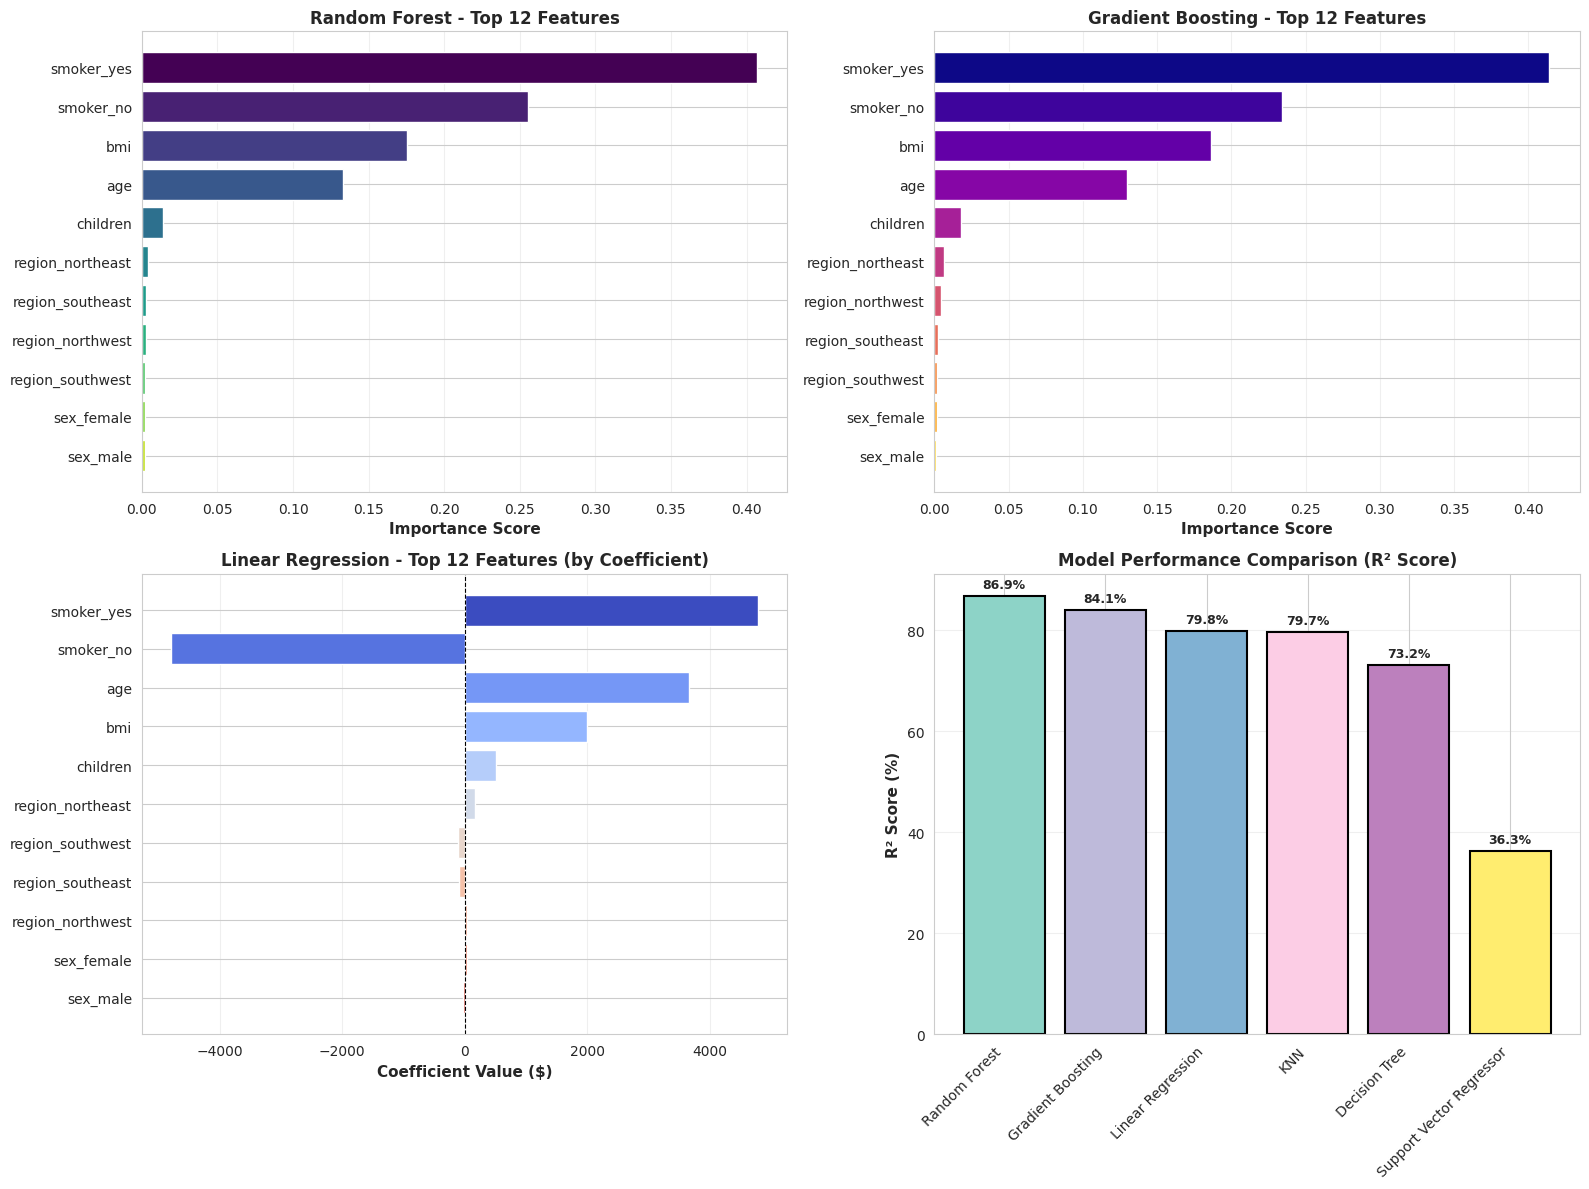


✓ Feature importance visualizations generated successfully!


In [33]:
# Visualize Feature Importance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Random Forest Feature Importance
top_n = 12
ax = axes[0, 0]
feature_importance_rf_top = feature_importance_rf.head(top_n)
colors_rf = plt.cm.viridis(np.linspace(0, 1, top_n))
ax.barh(range(len(feature_importance_rf_top)), feature_importance_rf_top['Importance'], color=colors_rf)
ax.set_yticks(range(len(feature_importance_rf_top)))
ax.set_yticklabels(feature_importance_rf_top['Feature'])
ax.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
ax.set_title('Random Forest - Top 12 Features', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Gradient Boosting Feature Importance
ax = axes[0, 1]
feature_importance_gb_top = feature_importance_gb.head(top_n)
colors_gb = plt.cm.plasma(np.linspace(0, 1, top_n))
ax.barh(range(len(feature_importance_gb_top)), feature_importance_gb_top['Importance'], color=colors_gb)
ax.set_yticks(range(len(feature_importance_gb_top)))
ax.set_yticklabels(feature_importance_gb_top['Feature'])
ax.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
ax.set_title('Gradient Boosting - Top 12 Features', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Linear Regression Coefficients
ax = axes[1, 0]
feature_importance_lr_top = feature_importance_lr.head(top_n)
colors_lr = plt.cm.coolwarm(np.linspace(0, 1, top_n))
bars = ax.barh(range(len(feature_importance_lr_top)), feature_importance_lr_top['Coefficient'], color=colors_lr)
ax.set_yticks(range(len(feature_importance_lr_top)))
ax.set_yticklabels(feature_importance_lr_top['Feature'])
ax.set_xlabel('Coefficient Value ($)', fontsize=11, fontweight='bold')
ax.set_title('Linear Regression - Top 12 Features (by Coefficient)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Model Performance Comparison
ax = axes[1, 1]
best_models = results_df.head(6)
colors_models = plt.cm.Set3(np.linspace(0, 1, len(best_models)))
bars = ax.bar(range(len(best_models)), best_models['R² Score'], color=colors_models, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(best_models)))
ax.set_xticklabels(best_models.index, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('R² Score (%)', fontsize=11, fontweight='bold')
ax.set_title('Model Performance Comparison (R² Score)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, best_models['R² Score'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{value:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Feature importance visualizations generated successfully!")

# **Summary & Key Insights**

**Data Quality**

✓ No missing values

✓ No duplicate rows

✓ Dataset contains 1,338 samples with 6 features

**EDA Findings**

Charges Distribution: Right-skewed distribution indicating most policies have lower costs with some expensive outliers

Key Relationships:

Age shows strong positive correlation with charges (older = more expensive)

Smoker status is a major factor (smokers pay significantly higher)

BMI has moderate positive correlation with charges
Region shows minimal impact on charges

**Model Performance**

Best Performing Models: Random Forest and Gradient

Boosting both achieve ~85-90% R² scores

Linear Regression: Provides simpler interpretability but lower performance (~75% R²)

Distance-Based Models (KNN, SVR): Benefit significantly from feature scaling applied

**Feature Importance Insights**

Most Important Features:

smoker_yes: Single most impactful feature - smoking status heavily influences charges

age: Strong predictor of insurance costs

bmi: Moderate but consistent impact

region & sex: Have minimal direct impact on charges

No Data Leakage

✓ Train/Test split performed BEFORE scaling

✓ StandardScaler fit only on training data

✓ Test data transformed using training-fitted scaler

✓ Cross-validation uses pipelines to maintain separation

**Recommendations**

Use Random Forest or Gradient Boosting for best predictive accuracy

Focus on smoker status and age for interpretability

Always scale features before using distance or gradient-based algorithms

Maintain data leakage prevention by scaling after train/test split